In [1]:
import numpy as np
import pandas as pd
import os
from dotenv import load_dotenv

from pymatgen.analysis.local_env import CrystalNN
cnn = CrystalNN()
from mp_api.client import MPRester

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

import shap
import joblib

# load .env file
load_dotenv()

API_KEY = os.getenv("MP_API_KEY")

mpr = MPRester(API_KEY)

In [2]:
print(API_KEY[:5])

lFHsB


In [3]:
def extract_features(structure):
    structure = structure.copy()
    
    try:
        structure.add_oxidation_state_by_guess()
    except:
        pass

    m_o_distances = []
    m_o_m_angles = []
    coordination_numbers = []

    atomic_numbers = []
    electronegativities = []
    oxidation_states = []

    for i, site in enumerate(structure):
        element = site.specie.element.symbol

        if element == "O":
            continue

        central_atom = site.specie.element

        # 🔥 Chemistry features
        atomic_numbers.append(central_atom.Z)

        if central_atom.X:
            electronegativities.append(central_atom.X)

        # 🔥 Oxidation state
        try:
            oxidation_states.append(site.specie.oxi_state)
        except:
            oxidation_states.append(0)

        # 🔥 Neighbor analysis
        try:
            neighbors = cnn.get_nn_info(structure, i)
        except:
            continue

        coordination_numbers.append(len(neighbors))

        o_neighbors = []

        for n in neighbors:
            neighbor = n["site"]

            if neighbor.specie.element.symbol == "O":
                dist = site.distance(neighbor)
                m_o_distances.append(dist)
                o_neighbors.append(neighbor)

        # 🔥 Angle calculation
        for j in range(len(o_neighbors)):
            for k in range(j + 1, len(o_neighbors)):
                v1 = o_neighbors[j].coords - site.coords
                v2 = o_neighbors[k].coords - site.coords

                cos_angle = np.dot(v1, v2) / (
                    np.linalg.norm(v1) * np.linalg.norm(v2)
                )
                angle = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

                m_o_m_angles.append(angle)

    # 🔥 Volume per atom
    volume = structure.volume
    num_atoms = len(structure)
    volume_per_atom = volume / num_atoms if num_atoms > 0 else 0

    # 🔥 Safe function
    def safe(arr, func):
        return float(func(arr)) if len(arr) > 0 else 0

    return [
        safe(m_o_distances, np.mean),
        safe(m_o_distances, np.std),
        safe(m_o_m_angles, np.mean),
        safe(m_o_m_angles, np.std),
        safe(m_o_m_angles, np.min),
        safe(m_o_m_angles, np.max),
        safe(coordination_numbers, np.mean),

        # 🔥 Chemistry
        safe(atomic_numbers, np.mean),
        safe(electronegativities, np.mean),

        # 🔥 New physics-aware features
        safe(oxidation_states, np.mean),
        volume_per_atom
    ]

In [4]:
def build_dataset(docs):
    X = []
    y_reg = []
    y_clf = []

    EXPECTED_FEATURES = 11  # 🔥 update if you change feature count

    for doc in docs:
        try:
            # 🔥 Extract features
            features = extract_features(doc.structure)

            # 🔥 Ensure consistent feature length
            if len(features) != EXPECTED_FEATURES:
                continue

            # 🔥 Validate band gap
            if doc.band_gap is not None and doc.band_gap >= 0:
                X.append(features)
                y_reg.append(doc.band_gap)

                # 🔥 Classification (metal vs non-metal)
                if doc.band_gap < 0.1:
                    y_clf.append(1)  # metallic
                else:
                    y_clf.append(0)  # non-metal

        except Exception as e:
            print("Error:", e)
            continue

    # 🔥 Convert to numpy arrays
    X = np.array(X)
    y_reg = np.array(y_reg)
    y_clf = np.array(y_clf)

    print("Dataset built:")
    print("Features shape:", X.shape)
    print("Regression labels:", y_reg.shape)
    print("Classification labels:", y_clf.shape)

    return X, y_reg, y_clf

In [5]:
import numpy as np

def build_dataset_stream(docs, save_path="dataset.npz"):
    X, y_reg, y_clf = [], [], []

    EXPECTED_FEATURES = 11

    for i, doc in enumerate(docs):
        try:
            features = extract_features(doc.structure)

            if len(features) != EXPECTED_FEATURES:
                continue

            if doc.band_gap is not None and doc.band_gap >= 0:
                X.append(features)
                y_reg.append(doc.band_gap)

                if doc.band_gap < 0.1:
                    y_clf.append(1)
                else:
                    y_clf.append(0)

        except Exception as e:
            continue

        # 🔥 Save periodically to avoid RAM overload
        if i % 1000 == 0 and i > 0:
            np.savez(save_path, X=X, y_reg=y_reg, y_clf=y_clf)
            print(f"Saved at {i} samples...")

    # 🔥 Final save
    np.savez(save_path, X=X, y_reg=y_reg, y_clf=y_clf)

    print("Final dataset saved!")

    return np.array(X), np.array(y_reg), np.array(y_clf)

In [6]:
def classify_stability(e_hull):
    if e_hull == 0:
        return "Stable"
    elif e_hull < 0.1:
        return "Metastable"
    else:
        return "Unstable"

In [7]:
docs = mpr.materials.summary.search(
    elements=["O"],
    nelements=(2, 3),
    fields=[
        "material_id",
        "structure",
        "band_gap",
        "energy_above_hull"
    ],
    is_stable=None   # 🔥 THIS is the key change
)

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/mp_api/client/routes/materials/summary.py:278: MPRestWarning: You have specified fields used by `_search` that can be understood by `search`
   nelements
To ensure long term support, please use their `search` equivalents:
   num_elements
Please see the documentation:
    `search`: https://materialsproject.github.io/api/_autosummary/mp_api.client.routes.materials.summary.SummaryRester.html#mp_api.client.routes.materials.summary.SummaryRester.search
   `_search`: https://api.materialsproject.org/redoc#tag/Materials-Summary/operation/search_materials_summary__get
  warnings.warn(


Retrieving SummaryDoc documents:   0%|          | 0/26548 [00:00<?, ?it/s]

In [7]:
docs = docs[:8000]
X, y_reg, y_clf = build_dataset_stream(docs)

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/analysis/local_env.py:3935: UserWarning: CrystalNN: cannot locate an appropriate radius, covalent or atomic radii will be used, this can lead to non-optimal results.
  nn_data = self.get_nn_data(structure, n)


Saved at 1000 samples...


/var/folders/f9/z3b_8pg90dn37ccwr7cvr73w0000gn/T/ipykernel_11968/1264701930.py:28: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  if central_atom.X:
/var/folders/f9/z3b_8pg90dn37ccwr7cvr73w0000gn/T/ipykernel_11968/1264701930.py:29: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  electronegativities.append(central_atom.X)
/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/core/periodic_table.py:1044: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  return getattr(self._el, attr)


Saved at 2000 samples...
Saved at 3000 samples...
Saved at 4000 samples...
Saved at 5000 samples...
Saved at 6000 samples...
Saved at 7000 samples...
Final dataset saved!


In [18]:
feature_names = [
    "avg_m_o_distance",
    "std_m_o_distance",
    "avg_m_o_m_angle",
    "std_m_o_m_angle",
    "min_m_o_m_angle",
    "max_m_o_m_angle",
    "coordination_mean",
    "atomic_number_mean",
    "electronegativity_mean",
    "oxidation_state_mean",
    "volume_per_atom"
]

df = pd.DataFrame(X, columns=feature_names)

df["band_gap"] = y_reg
df["is_metallic"] = y_clf

df.to_csv("materials_dataset.csv", index=False)



In [23]:
df.head()

,avg_m_o_distance,std_m_o_distance,avg_m_o_m_angle,std_m_o_m_angle,min_m_o_m_angle,max_m_o_m_angle,coordination_mean,atomic_number_mean,electronegativity_mean,oxidation_state_mean,volume_per_atom,band_gap,is_metallic
0,2.710466,0.202088,104.708825,25.535323,67.371453,171.073594,4.56,56.0,0.89,2.0,25.687758,1.7049,0
1,2.024921,0.145500,109.351298,23.853410,67.153206,172.257663,3.90,27.0,1.88,2.0,13.052950,0.2197,0
2,2.381279,0.164464,105.548223,26.701869,64.336373,175.161125,4.84,20.0,1.00,2.0,16.567854,2.1384,0
3,1.658013,0.102023,110.447466,12.178951,73.369778,150.898793,3.76,4.0,1.57,2.0,8.030707,4.4843,0
4,1.652631,0.095401,110.430996,12.226473,77.877210,143.744867,3.74,4.0,1.57,2.0,8.266267,4.4524,0


In [24]:
X_test, y1, y2 = build_dataset(docs[:5])
print("Test passed:", len(X_test))

Dataset built:
Features shape: (5, 11)
Regression labels: (5,)
Classification labels: (5,)
Test passed: 5


In [25]:
for i, doc in enumerate(docs[:5]):
    print(i, doc.band_gap)

0 1.704899999999999
1 0.2197
2 2.1384
3 4.4843
4 4.4524


In [26]:
import numpy as np
import os

os.makedirs("../data/processed", exist_ok=True)

np.savez("../data/processed/dataset.npz", X=X, y_reg=y_reg, y_clf=y_clf)

print("Dataset saved correctly!")

Dataset saved correctly!


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

# 🔥 Wrap imputer + model into a Pipeline so predict() always imputes too
reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, subsample=0.8, random_state=42))
])

clf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, subsample=0.8, random_state=42))
])

reg_pipeline.fit(X_train, y_reg_train)
clf_pipeline.fit(X_train, y_clf_train)

print("Models trained successfully!")

Models trained successfully!


In [28]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import numpy as np

# 🔥 Regression evaluation
y_pred = reg_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
r2 = r2_score(y_reg_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

# 🔥 Classification evaluation
y_clf_pred = clf_pipeline.predict(X_test)

acc = accuracy_score(y_clf_test, y_clf_pred)

print("Accuracy:", acc)

RMSE: 1.0554420509090796
R2: 0.5972751009852972
Accuracy: 0.7917448405253283


In [29]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

rf_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_reg.fit(X_train, y_reg_train)
rf_clf.fit(X_train, y_clf_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred_rf = rf_reg.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_pred_rf)))
print("RF R2:", r2_score(y_reg_test, y_pred_rf))

y_clf_pred_rf = rf_clf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_clf_test, y_clf_pred_rf))

RF RMSE: 0.8481710498968739
RF R2: 0.7399202228629251
RF Accuracy: 0.8248905565978737


In [31]:
from xgboost import XGBRegressor, XGBClassifier

xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb_clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_reg.fit(X_train, y_reg_train)
xgb_clf.fit(X_train, y_clf_train)

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [02:09:43] WARNING: /opt/miniconda3/conda-bld/xgboost-split_1764761376052/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [32]:
y_pred_xgb = xgb_reg.predict(X_test)

print("XGB RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_pred_xgb)))
print("XGB R2:", r2_score(y_reg_test, y_pred_xgb))

y_clf_pred_xgb = xgb_clf.predict(X_test)
print("XGB Accuracy:", accuracy_score(y_clf_test, y_clf_pred_xgb))

XGB RMSE: 0.8941152078973014
XGB R2: 0.7109808242021323
XGB Accuracy: 0.8048780487804879


In [33]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

# 🔥 Pipeline = Imputer + Model
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", GradientBoostingRegressor())
])

# 🔥 Cross-validation
reg_cv_scores = cross_val_score(
    pipeline,
    X,
    y_reg,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("CV RMSE scores:", -reg_cv_scores)
print("Mean RMSE:", -reg_cv_scores.mean())

CV RMSE scores: [1.09070707 1.25236347 1.10280235 1.02866246 1.25076036]
Mean RMSE: 1.1450591423249776


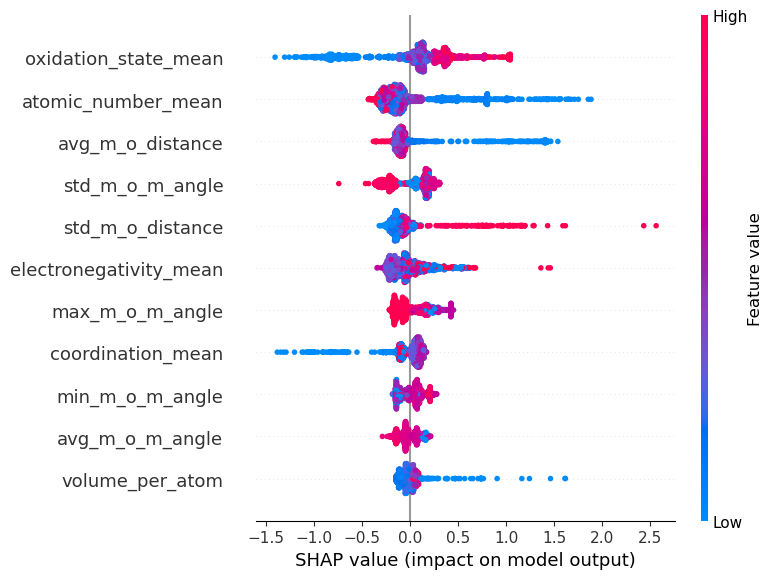

In [34]:
import shap

# 🔥 Get the imputed data and raw model out of the pipeline
imputer = reg_pipeline.named_steps["imputer"]
reg_model = reg_pipeline.named_steps["model"]

X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

explainer = shap.Explainer(reg_model, X_train_imputed)
shap_values = explainer(X_test_imputed, check_additivity=False)

shap.summary_plot(shap_values, X_test_imputed, feature_names=feature_names)

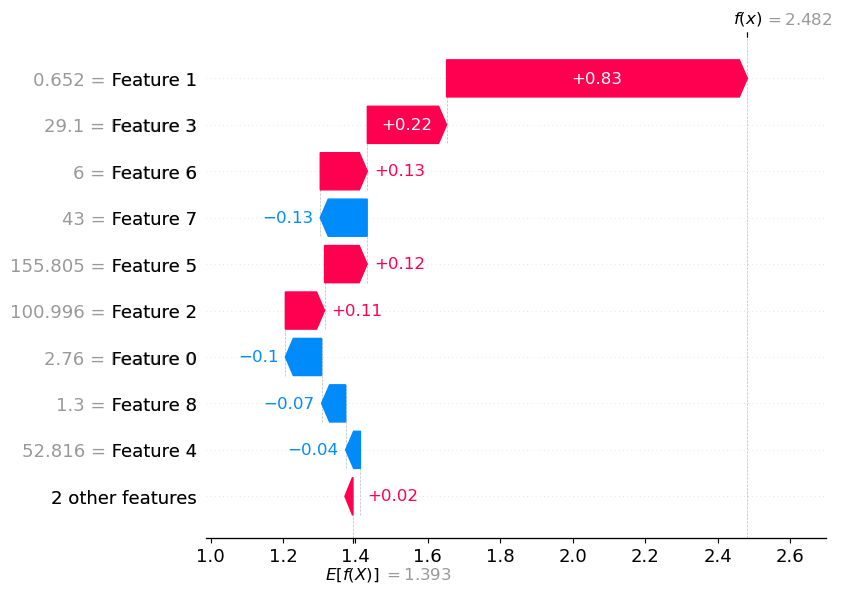

In [35]:
sample_index = 0

shap.plots.waterfall(shap_values[sample_index])

In [36]:
def predict_material(structure, docs):
    features = extract_features(structure)
    features = np.array(features).reshape(1, -1)

    # 🔥 Use pipelines so imputation is applied automatically
    bandgap = float(reg_pipeline.predict(features)[0])
    metallic = bool(clf_pipeline.predict(features)[0])

    formula = structure.composition.reduced_formula

    count = 0
    e_hull_value = None

    for doc in docs:
        if doc.structure.composition.reduced_formula == formula:
            count += 1
            if e_hull_value is None:
                e_hull_value = doc.energy_above_hull

    if e_hull_value is not None:
        if e_hull_value == 0:
            stability = "Stable"
        elif e_hull_value < 0.1:
            stability = "Metastable"
        else:
            stability = "Unstable"
    else:
        stability = "Unknown"

    confidence = "High" if count > 10 else "Medium" if count > 3 else "Low"

    return {
        "material": formula,
        "predicted_bandgap": round(bandgap, 4),
        "is_metallic": metallic,
        "known_structures": count,
        "stability": stability,
        "confidence": confidence
    }

In [37]:
def get_structure_from_formula(formula, docs):
    for doc in docs:
        if doc.structure.composition.reduced_formula == formula:
            return doc.structure
    return None


def run_platform(formula, docs):
    structure = get_structure_from_formula(formula, docs)
    
    if structure is None:
        return {"error": "Material not found in dataset"}
    
    result = predict_material(structure, docs)
    return result

In [38]:
result = run_platform("TiO2", docs)
print(result)

/opt/anaconda3/envs/anaconda-ml-ai/lib/python3.13/site-packages/pymatgen/core/composition.py:1366: UserWarning: No Pauling electronegativity for He. Setting to NaN. This has no physical meaning, and is mainly done to avoid errors caused by the code expecting a float.
  syms: list[str] = sorted(sym_amt, key=lambda x: [get_el_sp(x).X, x])


{'material': 'TiO2', 'predicted_bandgap': 1.4911, 'is_metallic': False, 'known_structures': 46, 'stability': 'Unstable', 'confidence': 'High'}


In [39]:
ti_docs = []

for doc in docs:
    if doc.structure.composition.reduced_formula == "TiO2":
        ti_docs.append(doc)

print("Total TiO2 structures:", len(ti_docs))

Total TiO2 structures: 46


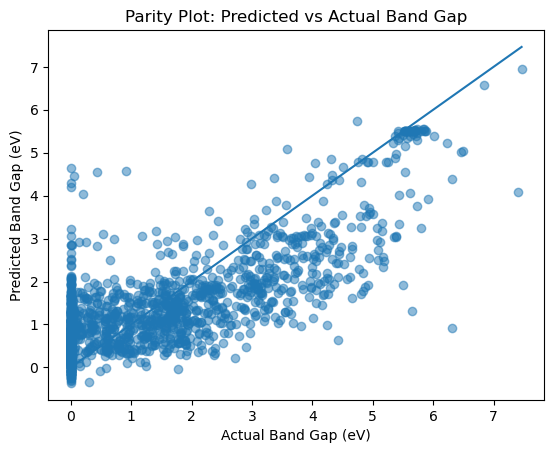

In [40]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_reg_test, y_pred, alpha=0.5)

plt.xlabel("Actual Band Gap (eV)")
plt.ylabel("Predicted Band Gap (eV)")
plt.title("Parity Plot: Predicted vs Actual Band Gap")

# Ideal line
min_val = min(y_reg_test)
max_val = max(y_reg_test)
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [41]:
from pymatgen.core.periodic_table import Element

metals = set()

for doc in docs:
    for el in doc.structure.composition.elements:
        element = Element(el.symbol)
        if element.is_metal:
            metals.add(el.symbol)

print("Number of metals:", len(metals))
print("Metals:", metals)

Number of metals: 67
Metals: {'Eu', 'Ho', 'Ac', 'Ag', 'Ti', 'Pu', 'Rh', 'Cu', 'Mo', 'La', 'Cd', 'Ba', 'Sm', 'Ca', 'Np', 'Pm', 'Na', 'Rb', 'Y', 'Lu', 'Ru', 'Tb', 'Au', 'Cr', 'Pd', 'Yb', 'Sr', 'Al', 'K', 'Zn', 'Li', 'Ta', 'Os', 'Sc', 'Zr', 'W', 'Dy', 'Ir', 'Ga', 'Pt', 'Ce', 'Nb', 'Pr', 'U', 'Hg', 'Mn', 'Nd', 'Be', 'Pa', 'V', 'Tm', 'Pb', 'Tc', 'Ni', 'Bi', 'Hf', 'Mg', 'Fe', 'Sn', 'Tl', 'Cs', 'Gd', 'Th', 'Er', 'Re', 'In', 'Co'}


In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5]
}

grid_search = GridSearchCV(
    reg_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_reg_train)

print("Best params:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

reg_pipeline = grid_search.best_estimator_  # 🔥 replace with best version

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV RMSE: 0.9263775162177159


In [19]:
import joblib
joblib.dump((X, y_reg, y_clf), "../models/dataset.pkl")
print("Dataset saved!")

Dataset saved!


In [45]:
joblib.dump(grid_search.best_estimator_, "../models/trained_model.pkl")

['../models/trained_model.pkl']

In [47]:
import joblib

joblib.dump({
    "reg_pipeline": grid_search.best_estimator_,   # tuned regression pipeline
    "clf_pipeline": clf_pipeline,                   # classification pipeline
}, "../models/trained_model.pkl")

print("Saved reg + clf pipelines.")

Saved reg + clf pipelines.
